## Molecular Dynamics of a Lennard‑Jones Gas

### Author: Łukasz Grzegrzółka

The goal of this assignment is to implement a two‑dimensional molecular dynamics (MD) simulation of a gas composed of particles interacting through the Lennard‑Jones potential, a simple but realistic model of intermolecular forces. The simulation is performed inside a square box with periodic boundary conditions, which mimic an infinite system by wrapping particles that leave one side of the box back to the opposite side. This avoids artificial wall effects and allows the system to behave like a bulk fluid.

The broader purpose of the exercise is to understand how microscopic dynamics - the positions, velocities, and forces acting on individual particles - give rise to macroscopic thermodynamic quantities, such as temperature, pressure, and total energy. This is a central idea in statistical mechanics: macroscopic observables emerge as time‑averaged properties of many‑particle systems evolving according to Newton’s laws.

The assignment also introduces the concept of thermostats, numerical techniques used to control the temperature of an MD simulation. Real experiments are typically performed at constant temperature, but a purely Newtonian simulation corresponds to an isolated system with fixed total energy. A thermostat modifies the equations of motion to maintain a target temperature, allowing the simulation to sample the canonical ensemble.

In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import imageio.v2 as imageio

particle_number = 16
box_size = 8.0
eps = 1.
sigma = 1.
rad = sigma / 2
dt = 0.0001
temp = 25
k = 1
m = 1
Ep0 = 2*eps*( (sigma / 2.5)**12 - (sigma / 2.5)**6 )

class Particle:
    
    def __init__(self, r, v):
        self.r = np.array(r)
        self.v = np.array(v)            #prędkość docelowo cofana o pół kroku w tył
        self.vu = np.array(v)           #prędkość obecna, wykorzystywana przy termostacie
        
    def move(self, dt, F=0):
        self.v = self.v + (F/m) * dt
        self.r = (self.r + dt * self.v) % box_size
        
    def update_vu(self, dt, F=0):
        self.vu = self.v + (F/m) * dt/2
        
    def update_r(self, dt, eta, F=0):
        self.v = (2*eta - 1)*self.v + eta/m*dt * F
        self.r = (self.r + dt * self.v) % box_size
        
    def distance(self, other):
        dx = self.r[0] - other.r[0]
        dy = self.r[1] - other.r[1]
        
        if dx > box_size/2:
            dx -= box_size
        if dx < -box_size/2:
            dx += box_size
            
        if dy > box_size/2:
            dy -= box_size
        if dy < -box_size/2:
            dy += box_size

        return np.sqrt(dx**2+dy**2)
    
    def vec(self, other):
        vec = np.array([self.r[0] - other.r[0], self.r[1] - other.r[1]])
        if vec[0] > box_size/2:
            vec[0] -= box_size
        if vec[0] < -box_size/2:
            vec[0] += box_size
            
        if vec[1] > box_size/2:
            vec[1] -= box_size
        if vec[1] < -box_size/2:
            vec[1] += box_size
        return vec
        
    def force(self, other):
        r = self.distance(other)
        
        if r == 0:
            return np.zeros(2)
        
        if r > 2.5 * sigma:
            return np.zeros(2)
        
        coeff = 48*eps/sigma**2*((sigma/r)**14 - (1/2)*(sigma/r)**8)
        vec = self.vec(other)

        
        return coeff*vec
        

class Set_of_particles:

    def __init__(self, N):
        self.N = N
        self.particles_list = []
        for i in range(int(np.sqrt(N))):
            for j in range(int(np.sqrt(N))):
                self.particles_list.append(Particle([2*i+1, 2*j+1], [random.uniform(0, 1), random.uniform(0, 1)]))
                #self.particles_list.append(Particle([1.5*i+1, 1.5*j+1], [random.uniform(0, 1), random.uniform(0, 1)]))

        V_mean = np.zeros(2)
        for particle in self.particles_list:
            V_mean += particle.v
        V_mean /= self.N

        for particle in self.particles_list:
            particle.v -= V_mean

        V2 = 0
        for particle in self.particles_list:
            V2 += np.dot(particle.v, particle.v)

        for particle in self.particles_list:
            particle.v /= np.sqrt(V2)
            particle.v *= np.sqrt(2*k*temp*N/m)
            
        #print(sum([p.v[0] for p in self.particles_list]), sum([p.v[1] for p in self.particles_list]))
        #print(sum([(p.v[0]**2 + p.v[1]**2)*m/2 for p in self.particles_list])/N)

        self.t_list = []
        self.E_list = []
        self.p_list = []
        self.Ek_list = []
        self.Ep_list = []


        F = np.zeros((self.N, self.N, 2))
       
        for i in range(self.N):
            for j in range(self.N):
                F[i, j] = self.particles_list[i].force(self.particles_list[j])
                
        for i in range(self.N):
            self.particles_list[i].v -= 1/m*np.sum(F[i, :], axis = 0)*dt/2

    def forces(self):
        F = np.zeros((self.N, self.N, 2))
       
        for i in range(self.N):
            for j in range(self.N):
                F[i, j] = self.particles_list[i].force(self.particles_list[j])
        return F
    
    def evolve(self, dt):
        F = self.forces()
        #F = np.zeros((self.N, self.N, 2))     #dla gazu swobodnego
        for i in range(self.N):
            self.particles_list[i].move(dt/2, np.sum(F[i, :], axis = 0))
            
            
        self.t_list.append(self.temperature())
        self.Ep_list.append(self.E_p())
        self.Ek_list.append(self.E_k())
        self.E_list.append(self.Ek_list[-1]+ self.Ep_list[-1])
        self.p_list.append(self.pressure())

    def evolve_termostat(self, dt):
        F = self.forces()       
        """
        for i in range(self.N):
            self.particles_list[i].update_vu(dt, np.sum(F[i, :], axis = 0))
            """
 
        eta = np.sqrt(temp/self.temperature())
        F = self.forces()       
        for i in range(self.N):
            self.particles_list[i].update_r(dt, eta, np.sum(F[i, :], axis = 0))
            
        self.t_list.append(self.temperature())
        self.Ep_list.append(self.E_p())
        self.Ek_list.append(self.E_k())
        self.E_list.append(self.Ek_list[-1]+ self.Ep_list[-1])
        self.p_list.append(self.pressure())


    def E_k(self):
        E = sum(m*np.dot(particle.v, particle.v) for particle in self.particles_list)/2
        return E

    def E_p(self):
        E=0
        for i in range(self.N):
            for j in range(i):
                r = self.particles_list[i].distance(self.particles_list[j])
                if r <= 2.5:
                    E += 4*eps*((sigma / r)**12 - (sigma/r)**6) - Ep0
        return E
    
    def E_c(self):
        return self.E_k() + self.E_p()
    
    def temperature(self):
        return (self.E_k())/(self.N*k)
    
    def pressure(self):
        return (self.N * k * self.temperature() /box_size**2 
                - (sum([np.dot(self.particles_list[i].vec(self.particles_list[j]), self.particles_list[j].force(self.particles_list[i])) for i in range(self.N) for j in range(i)] )
                    )/2/box_size**2)

### Lennard‑Jones Gas Without a Thermostat

In the first part of the task, the system evolves according to the standard leapfrog (Verlet‑type) integrator, which is well suited for Hamiltonian dynamics because it conserves energy and preserves phase‑space volume. Each particle interacts with all others through the truncated and shifted Lennard‑Jones potential, which captures short‑range repulsion and longer‑range attraction. The forces are computed using the minimum‑image convention, ensuring that each particle interacts only with the nearest periodic copy of every other particle.

As the simulation runs, the code records:

- the instantaneous temperature, computed from the kinetic energy,

- the potential, kinetic, and total energy,

- the pressure, obtained from the virial expression.

The animation generated from the simulation shows particles moving freely, colliding, and exchanging energy. Because no thermostat is applied, the total energy remains constant (up to numerical fluctuations), and the temperature fluctuates naturally according to the equipartition theorem. This setup corresponds to the microcanonical ensemble, where the system is isolated and energy is conserved. This part of the assignment demonstrates how microscopic Newtonian motion produces emergent thermodynamic behaviour, and how quantities like temperature and pressure can be computed directly from particle trajectories.

#### Link to the animation:

https://github.com/lukasz23g/Computer-simulations-of-physical-phenomena-2023-2024/blob/main/Gas.gif

In [7]:
from tqdm import tqdm

particles = Set_of_particles(particle_number)
#particles.pressure()


filenames = []

def plot(i):
    plt.clf()
    fig = plt.gcf()
    for p in particles.particles_list:
        a = plt.gca()
        cir = Circle((p.r[0], p.r[1]), radius = rad)
        a.add_patch(cir)
        plt.plot()
    plt.xlim((0, box_size))
    plt.ylim((0, box_size))
    fig.set_size_inches((6, 6))
    plt.title(f'Symulacja gazu, krok {i:06d}')
    plt.savefig(rf'gas_plots\img{i:06d}.png')
    filenames.append(rf'gas_plots\img{i:06d}.png')
    
for i in tqdm(range(30000)):
    if i % 100 == 0:
        plot(i)
    particles.evolve(dt)

plt.close()


100%|██████████| 30000/30000 [01:33<00:00, 322.46it/s]


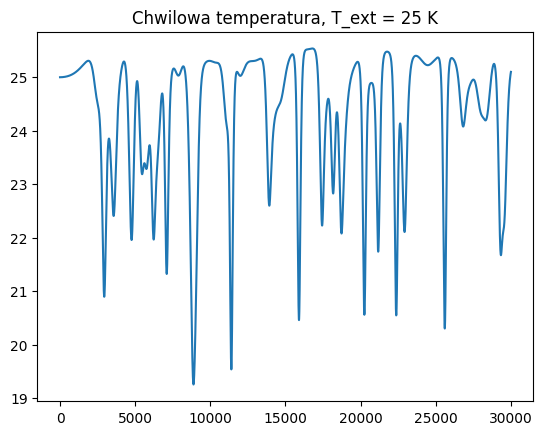

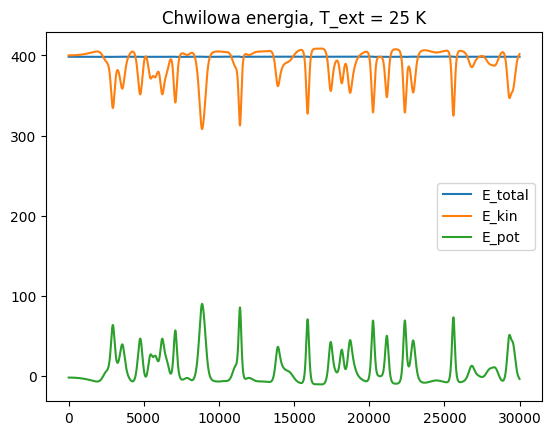

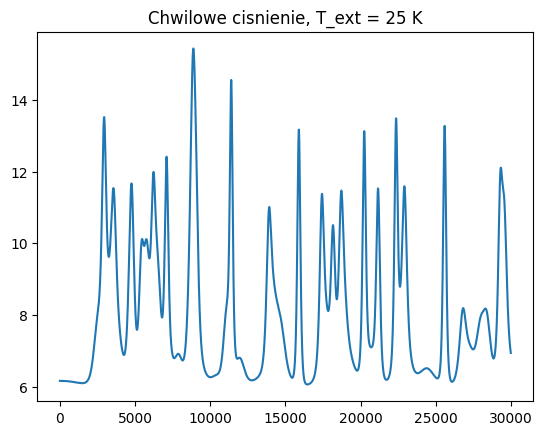

In [8]:
with imageio.get_writer('Gas.gif', mode = 'I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
    plt.close()


plt.figure()
plt.plot(particles.t_list)
plt.title(f'Chwilowa temperatura, T_ext = {temp} K')
plt.show()

plt.figure()
plt.plot(particles.E_list, label="E_total")
plt.plot(particles.Ek_list, label="E_kin")
plt.plot(particles.Ep_list, label="E_pot")
plt.legend()
plt.title(f'Chwilowa energia, T_ext = {temp} K')
plt.show()

plt.figure()
plt.plot(particles.p_list)
plt.title(f'Chwilowe cisnienie, T_ext = {temp} K')
plt.show()

### Lennard‑Jones Gas With an Isokinetic Thermostat

In the second part, the simulation is modified to include the isokinetic thermostat of Brown and Clarke. This thermostat rescales particle velocities at each step in such a way that the instantaneous kinetic energy remains fixed, enforcing a constant temperature throughout the simulation. The leapfrog update is adjusted by a scaling factor $\eta$, computed from the ratio of the target temperature to the current kinetic temperature.

The thermostat ensures that:

- the temperature remains extremely close to the desired value,

- the kinetic energy does not fluctuate,

- the system samples a constrained version of the canonical ensemble.

However, the isokinetic thermostat also modifies the true Newtonian dynamics, suppressing natural temperature fluctuations and altering the distribution of microstates. This highlights an important conceptual point: thermostats allow us to control macroscopic conditions, but they do so at the cost of changing the underlying equations of motion.

The resulting animation shows a system whose microscopic motion is similar to the unthermostatted case, but whose macroscopic observables - temperature and pressure - remain tightly regulated. The energy plots reveal that the kinetic energy is fixed by construction, while the potential energy fluctuates around a stable mean.

#### Link to the animation:

https://github.com/lukasz23g/Computer-simulations-of-physical-phenomena-2023-2024/blob/main/Gas_thermo.gif

In [9]:
from tqdm import tqdm

particles = Set_of_particles(particle_number)


filenames = []

def plot_thermo(i):
    plt.clf()
    fig = plt.gcf()
    for p in particles.particles_list:
        a = plt.gca()
        cir = Circle((p.r[0], p.r[1]), radius = rad)
        a.add_patch(cir)
        plt.plot()
    plt.xlim((0, box_size))
    plt.ylim((0, box_size))
    fig.set_size_inches((6, 6))
    plt.title(f'Symulacja gazu, krok {i:06d}')
    plt.savefig(rf'thermo_plots\img{i:06d}.png')
    filenames.append(rf'thermo_plots\img{i:06d}.png')
    
for i in tqdm(range(30000)):
    if i % 100 == 0:
        plot_thermo(i)
    particles.evolve_termostat(dt)

plt.close()

100%|██████████| 30000/30000 [02:04<00:00, 241.18it/s]


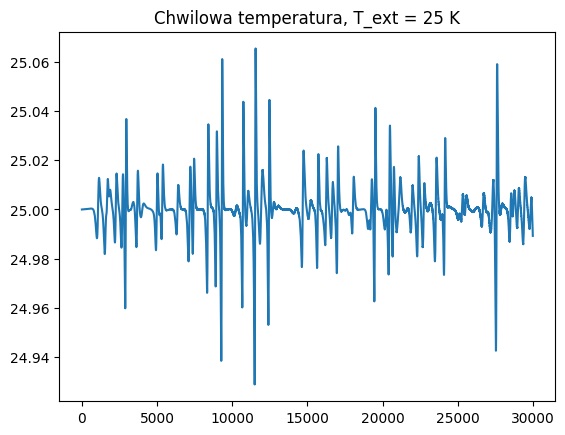

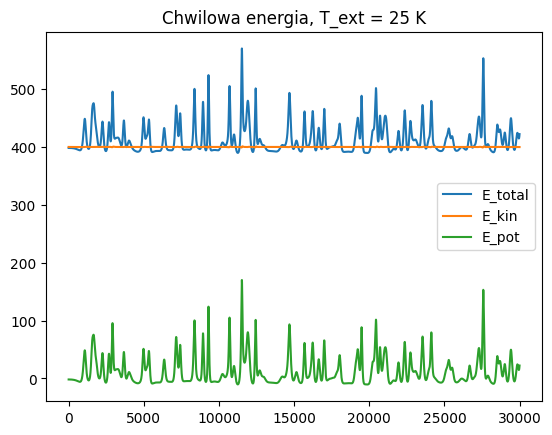

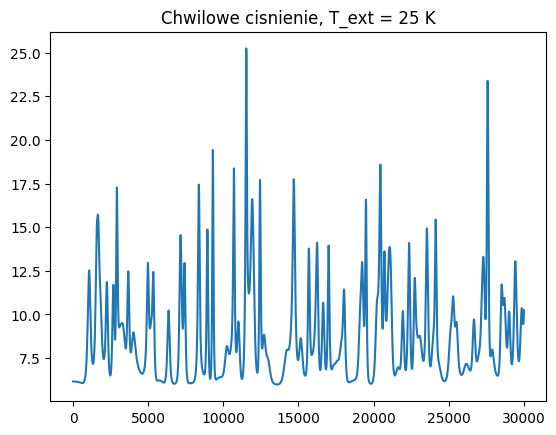

In [10]:
with imageio.get_writer('Gas_thermo.gif', mode = 'I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
    plt.close()


plt.figure()
plt.plot(particles.t_list)
plt.title(f'Chwilowa temperatura, T_ext = {temp} K')
plt.show()

plt.figure()
plt.plot(particles.E_list, label="E_total")
plt.plot(particles.Ek_list, label="E_kin")
plt.plot(particles.Ep_list, label="E_pot")
plt.legend()
plt.title(f'Chwilowa energia, T_ext = {temp} K')
plt.show()

plt.figure()
plt.plot(particles.p_list)
plt.title(f'Chwilowe cisnienie, T_ext = {temp} K')
plt.show()